<a href="https://colab.research.google.com/github/rakhmanavfarrukh-svg/CelebritySimilarityAI/blob/main/05_ml_05_amaliyot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Imgur](https://i.imgur.com/5pXzCIu.png)

# Data Science va Sun'iy Intellekt Praktikum

## 5-MODUL. Machine Learning

### Portfolio uchun vazifa: Toshkent shahrida uylarning narxini aniqlash.

Ushbu amaliyotda sizning vazifangiz berilgan ma`lumotlar asosida Toshkent shahridagi uylarning narxini aniqlash.

In [8]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/main/housing_data_08-02-2021.csv')
df.head()

,location,district,rooms,size,level,max_levels,price
0,"город Ташкент, Юнусабадский район, Юнусабад 8-...",Юнусабадский,3,57,4,4,52000
1,"город Ташкент, Яккасарайский район, 1-й тупик ...",Яккасарайский,2,52,4,5,56000
2,"город Ташкент, Чиланзарский район, Чиланзар 2-...",Чиланзарский,2,42,4,4,37000
3,"город Ташкент, Чиланзарский район, Чиланзар 9-...",Чиланзарский,3,65,1,4,49500
4,"город Ташкент, Чиланзарский район, площадь Актепа",Чиланзарский,3,70,3,5,55000


# Ustunlar ta'rifi
- `location` - sotilayotgan uy manzili
- `district` - uy joylashgan tuman
- `rooms` - xonalar soni
- `size` - uy maydoni (kv.m)
- `level` - uy joylashgan qavat
- `max_levels` - ja'mi qavatlar soni
- `price` - uy narxi

## Vazifani CRSIP-DM Metolodgiyasi yordamida bajaring.
<img src="https://i.imgur.com/dzZnnYi.png" alt="CRISP-DM" width="800"/>

Here we can see the columns size and price are being as an object, first we should solve this problem to see our dataframe fully.


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7565 entries, 0 to 7564
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   location    7565 non-null   object
 1   district    7565 non-null   object
 2   rooms       7565 non-null   int64 
 3   size        7565 non-null   object
 4   level       7565 non-null   int64 
 5   max_levels  7565 non-null   int64 
 6   price       7565 non-null   object
dtypes: int64(3), object(4)
memory usage: 413.8+ KB


In [10]:
display(df['size'].unique())
#here also there are numbers like 47.94 like this and the string 'Площадьземли:1сот'

array(['57', '52', '42', '65', '70', '28', '30', '32', '51', '67', '35',
       '43', '90', '80', '69', '96', '76', '45', '27', '64', '26', '72',
       '100', '63', '48', '102', '78', '34', '56', '98', '93', '60', '82',
       '120', '110', '95', '68', '46', '40', '53', '54', '20', '50', '36',
       '58', '74', '94', '85', '125', '64.67', '22', '66', '37', '61',
       '69.65', '88', '38', '55.13', '91', '111', '107', '62', '40.41',
       '75', '84', '117', '47', '33', '187', '29', '11', '122', '119',
       '164', '92', '55', '89', '208', '44', '86', '150', '56.10', '83',
       '49', '142', '115', '350', '81', '89.55', '59', '145', '116', '77',
       '24', '41', '255', '266', '210', '55.62', '140', '141', '60.94',
       '165', '215', '66.82', '128', '97', '130', '105', '137', '47.14',
       '71', '160', '118', '152', '21', '104', '180', '109', '135', '73',
       '39', '39.11', '157', '112', '93.22', '106', '214', '235', '16',
       '300', '57.95', '79', '5', '53.06', '62.50',

In [11]:
display(df['price'].unique())
#we can see here there is a value "Договорная" in price column so it being called like an object

array(['52000', '56000', '37000', '49500', '55000', '25500', '21200',
       '20000', '26200', '22200', '24200', '30200', '22500', '32500',
       '45000', '47000', '49900', '76000', '65000', '47500', '30000',
       '32000', '44000', '56500', '35000', '23500', '60500', '68000',
       '41500', '52500', '43000', '80000', '42000', '23000', '88784',
       '97000', '28500', '34500', '51000', '48000', '40000', '67000',
       '40500', '54000', '36000', '63000', '63500', '70000', '91000',
       '83000', '19765', '50000', '86000', '31500', '26500', '14500',
       '27000', '59500', '47299', '38000', '29500', '61500', '46500',
       '58400', '26000', '105000', '53500', '12500', '107000', '39414',
       '60000', '49000', '18000', '42500', '45800', '24000', '58000',
       '55500', '31000', '41000', '50500', '13071', '45188', '53000',
       '25600', '35226', '36500', '142000', '85000', '110000', '69000',
       '28900', '34000', '25000', '39000', '125000', '28000', '43500',
       '39999',

here we cleaned our column size
1.Finding the values not numeric
2.Inplace them with NaN
3.drop all NaNs
4.round() the numbers
5.object to int64


In [12]:
df['size'] = pd.to_numeric(df['size'], errors='coerce')
df.dropna(subset=['size'], inplace=True)
df['size'] = df['size'].round()
df['size'] = df['size'].astype('int64')
display(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 7564 entries, 0 to 7564
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   location    7564 non-null   object
 1   district    7564 non-null   object
 2   rooms       7564 non-null   int64 
 3   size        7564 non-null   int64 
 4   level       7564 non-null   int64 
 5   max_levels  7564 non-null   int64 
 6   price       7564 non-null   object
dtypes: int64(4), object(3)
memory usage: 472.8+ KB


None

we done the same thing like we do for size column

In [13]:
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df.dropna(subset=['price'], inplace=True)
df['price'] = df['price'].astype('int64')
display(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 7465 entries, 0 to 7564
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   location    7465 non-null   object
 1   district    7465 non-null   object
 2   rooms       7465 non-null   int64 
 3   size        7465 non-null   int64 
 4   level       7465 non-null   int64 
 5   max_levels  7465 non-null   int64 
 6   price       7465 non-null   int64 
dtypes: int64(5), object(2)
memory usage: 466.6+ KB


None

In [14]:
df.describe()

,rooms,size,level,max_levels,price
count,7465.000000,7465.000000,7465.000000,7465.000000,7.465000e+03
mean,2.622103,113.536906,3.693771,6.023979,7.132367e+04
std,1.083155,1501.158023,2.236905,2.607103,6.405659e+05
min,1.000000,1.000000,1.000000,1.000000,2.000000e+00
25%,2.000000,50.000000,2.000000,4.000000,3.500000e+04
50%,3.000000,65.000000,3.000000,5.000000,4.650000e+04
75%,3.000000,85.000000,5.000000,9.000000,6.700000e+04
max,10.000000,70000.000000,19.000000,25.000000,5.200000e+07


There are some inconsistent and invalid values in the size and price columns, so they need to be cleaned.
he dataset contains house data from 2021. The most expensive house sold in 2021 is around $2,600,000. However, to reduce the impact of extreme values and focus on the majority of observations, we set an upper limit of $1,000,000 for the price column.

In [15]:
df_filtered=df = df[(df['size'] < 500) & (df['price'] < 1000000)]
df_filtered.describe()


,rooms,size,level,max_levels,price
count,7445.000000,7445.000000,7445.000000,7445.000000,7445.000000
mean,2.620551,73.095635,3.696038,6.027938,59035.582942
std,1.081142,37.309865,2.237723,2.607809,46728.531198
min,1.000000,1.000000,1.000000,1.000000,2.000000
25%,2.000000,50.000000,2.000000,4.000000,35000.000000
50%,3.000000,65.000000,3.000000,5.000000,46000.000000
75%,3.000000,85.000000,5.000000,9.000000,66500.000000
max,10.000000,456.000000,19.000000,25.000000,800000.000000


It is time to visualisation

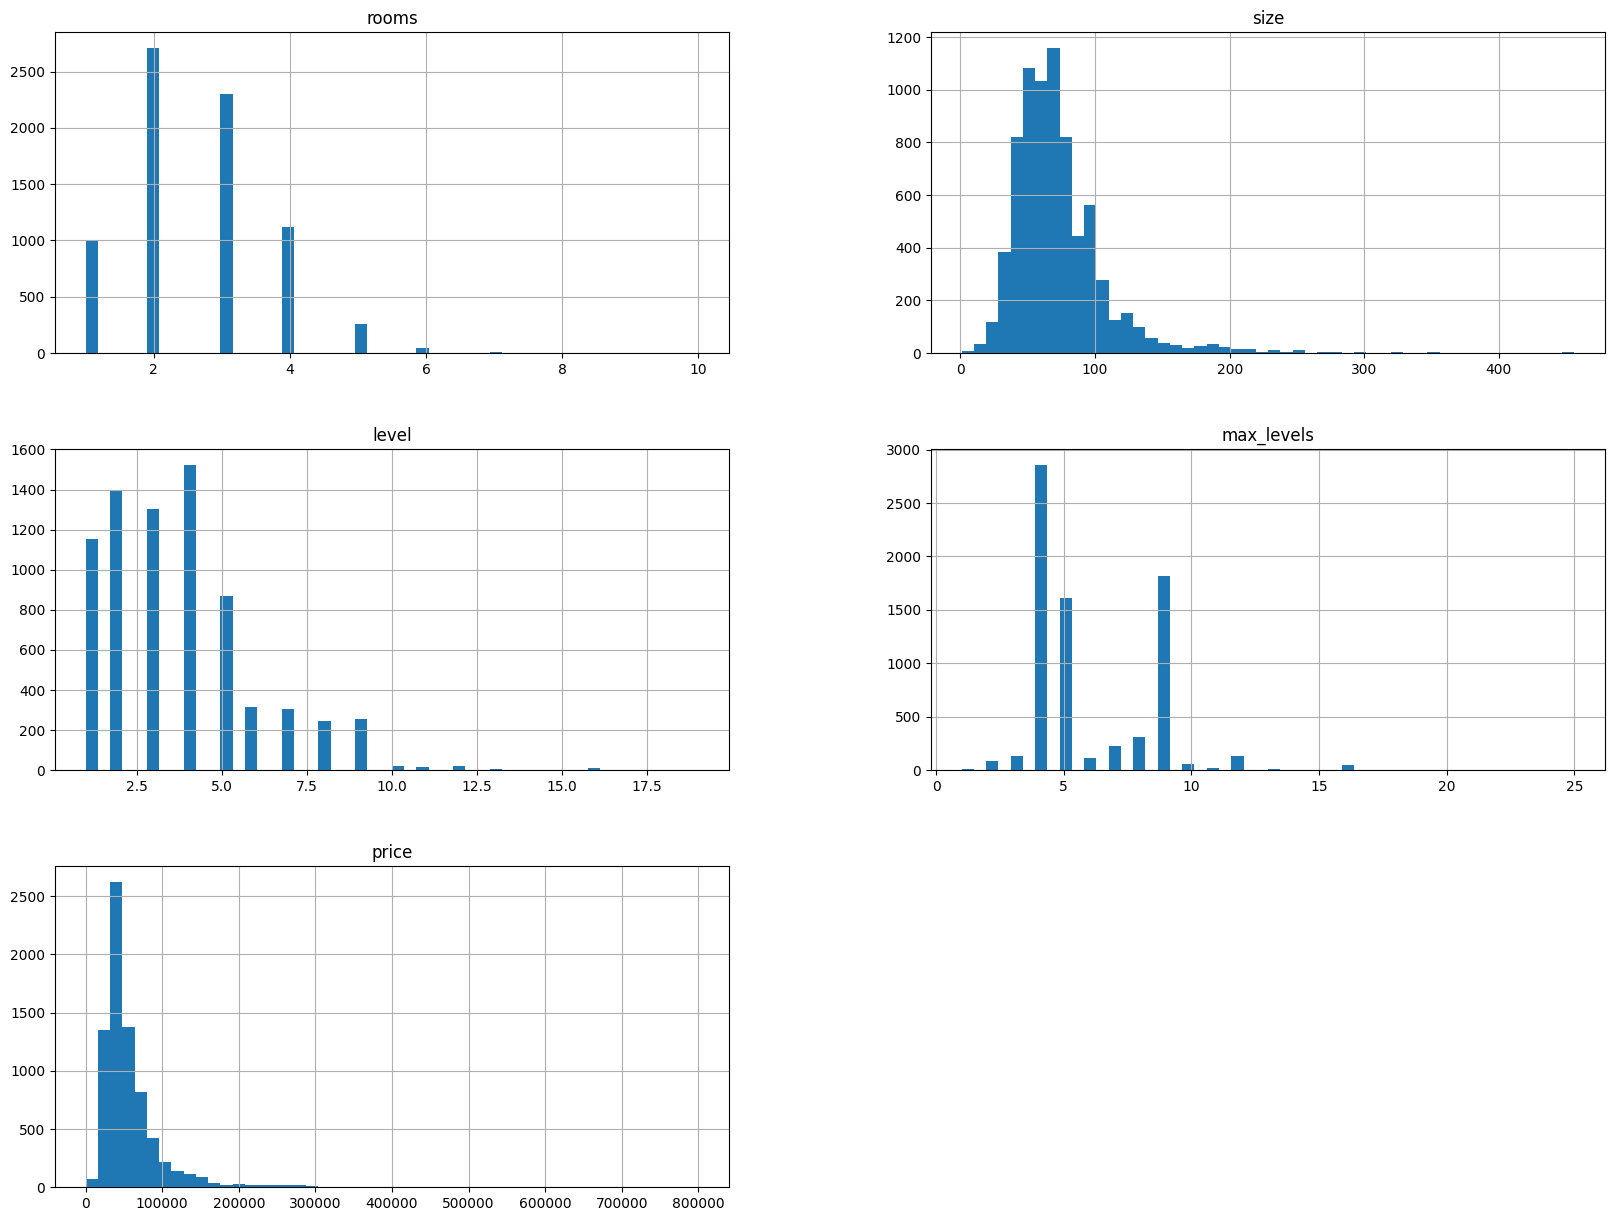

In [30]:
%matplotlib inline
df.hist(bins=50, figsize=(20,15))
plt.show()

I split the dataset into training (80%) and test (20%) sets to evaluate the model’s performance.


In [17]:
from sklearn.model_selection import train_test_split
train_set,test_set = train_test_split(df, test_size=0.2, random_state=42)


In [18]:
train_set.head(10)

,location,district,rooms,size,level,max_levels,price
761,"город Ташкент, Олмазорский район, Бируни-1",Олмазорский,4,150,5,6,95000
1522,"город Ташкент, Чиланзарский район, Домбрабад",Чиланзарский,1,42,3,9,31500
1938,"город Ташкент, Яккасарайский район, Кушбеги",Яккасарайский,3,76,5,9,43500
4285,"город Ташкент, Мирзо-Улугбекский район, Феруза 1",Мирзо-Улугбекский,2,48,1,4,28000
4117,"город Ташкент, Юнусабадский район, Киёт",Юнусабадский,1,43,3,4,39000
1944,"город Ташкент, Мирзо-Улугбекский район, Феруза-1",Мирзо-Улугбекский,1,36,4,4,21000
5121,"город Ташкент, Мирзо-Улугбекский район, Карасу...",Мирзо-Улугбекский,4,93,3,5,60000
3440,"город Ташкент, Мирзо-Улугбекский район, Буюк И...",Мирзо-Улугбекский,2,70,3,9,90000
1069,"город Ташкент, Чиланзарский район, Домбрабад",Чиланзарский,2,47,4,4,33000
636,"город Ташкент, Чиланзарский район, Катта козир...",Чиланзарский,2,52,3,4,41500


In [19]:
housing = train_set.copy()
housing.head()

,location,district,rooms,size,level,max_levels,price
761,"город Ташкент, Олмазорский район, Бируни-1",Олмазорский,4,150,5,6,95000
1522,"город Ташкент, Чиланзарский район, Домбрабад",Чиланзарский,1,42,3,9,31500
1938,"город Ташкент, Яккасарайский район, Кушбеги",Яккасарайский,3,76,5,9,43500
4285,"город Ташкент, Мирзо-Улугбекский район, Феруза 1",Мирзо-Улугбекский,2,48,1,4,28000
4117,"город Ташкент, Юнусабадский район, Киёт",Юнусабадский,1,43,3,4,39000


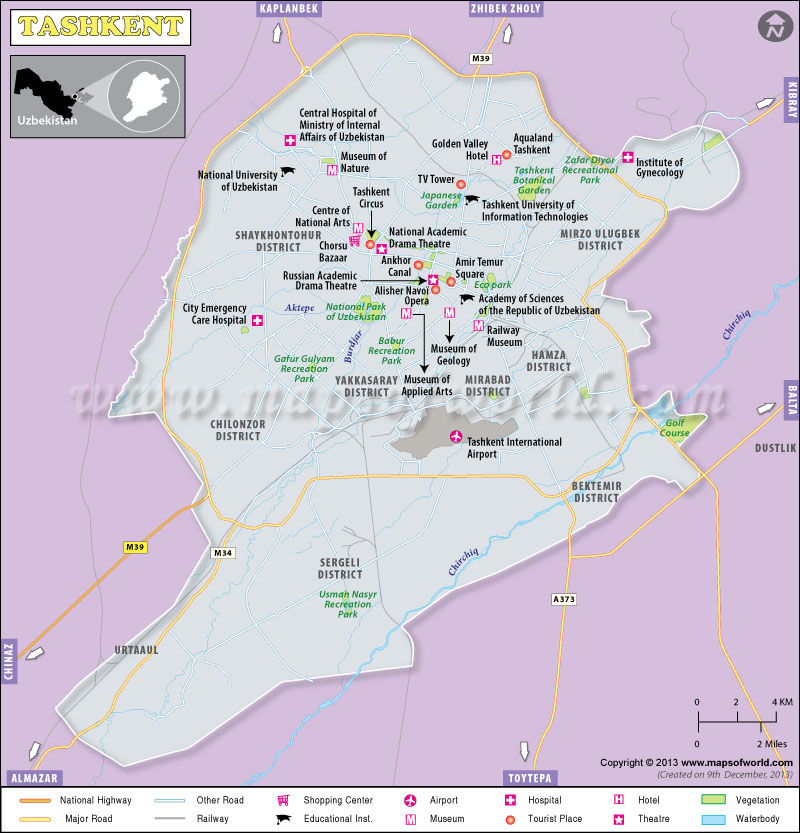

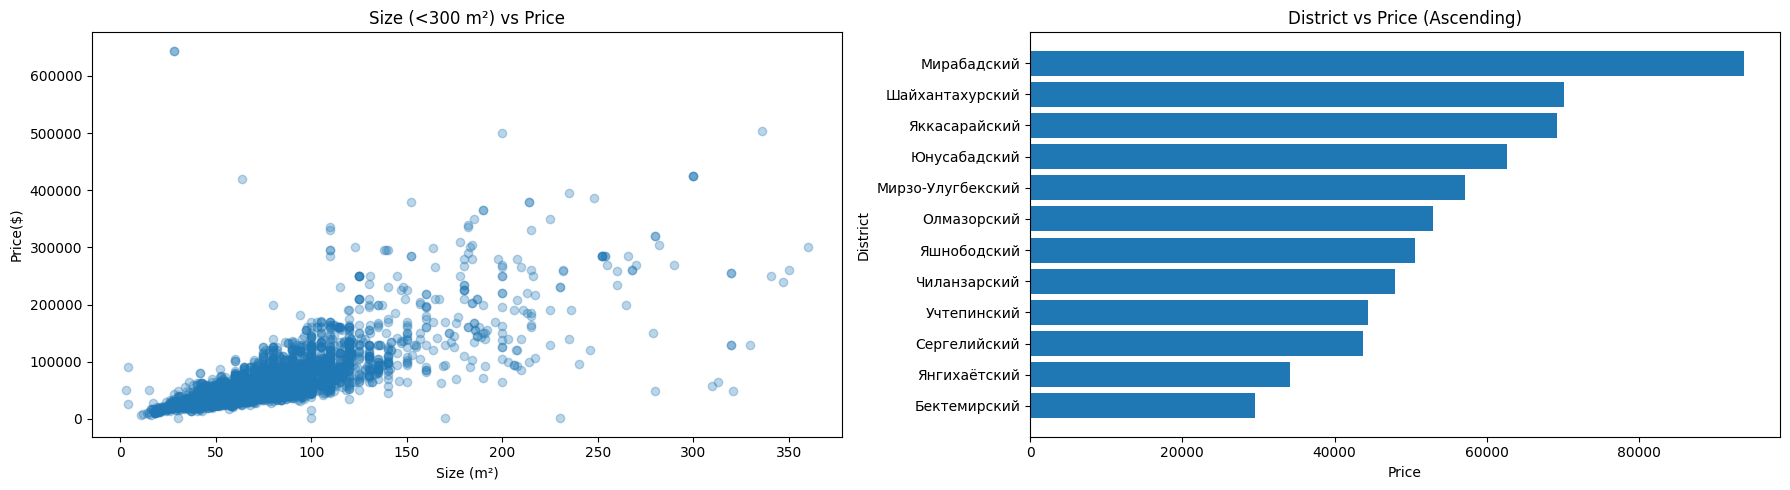

In [20]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(18,5))
filtered_size = housing[housing['size'] < 400]
axs[0].scatter(filtered_size['size'], filtered_size['price'], alpha=0.3)
axs[0].set_title('Size (<300 m²) vs Price')
axs[0].set_xlabel('Size (m²)')
axs[0].set_ylabel('Price($)')

district_sorted = housing.groupby('district')['price'].mean().sort_values()
axs[1].barh(district_sorted.index, district_sorted.values)
axs[1].set_title('District vs Price (Ascending)')
axs[1].set_xlabel('Price')
axs[1].set_ylabel('District')


plt.tight_layout()
plt.show()

In [21]:
housing.corrwith(housing['price'], numeric_only=True).sort_values(ascending=False)

,0
price,1.000000
size,0.761635
rooms,0.538588
max_levels,0.224509
level,0.069912


now we can see the corelation as a graph and number


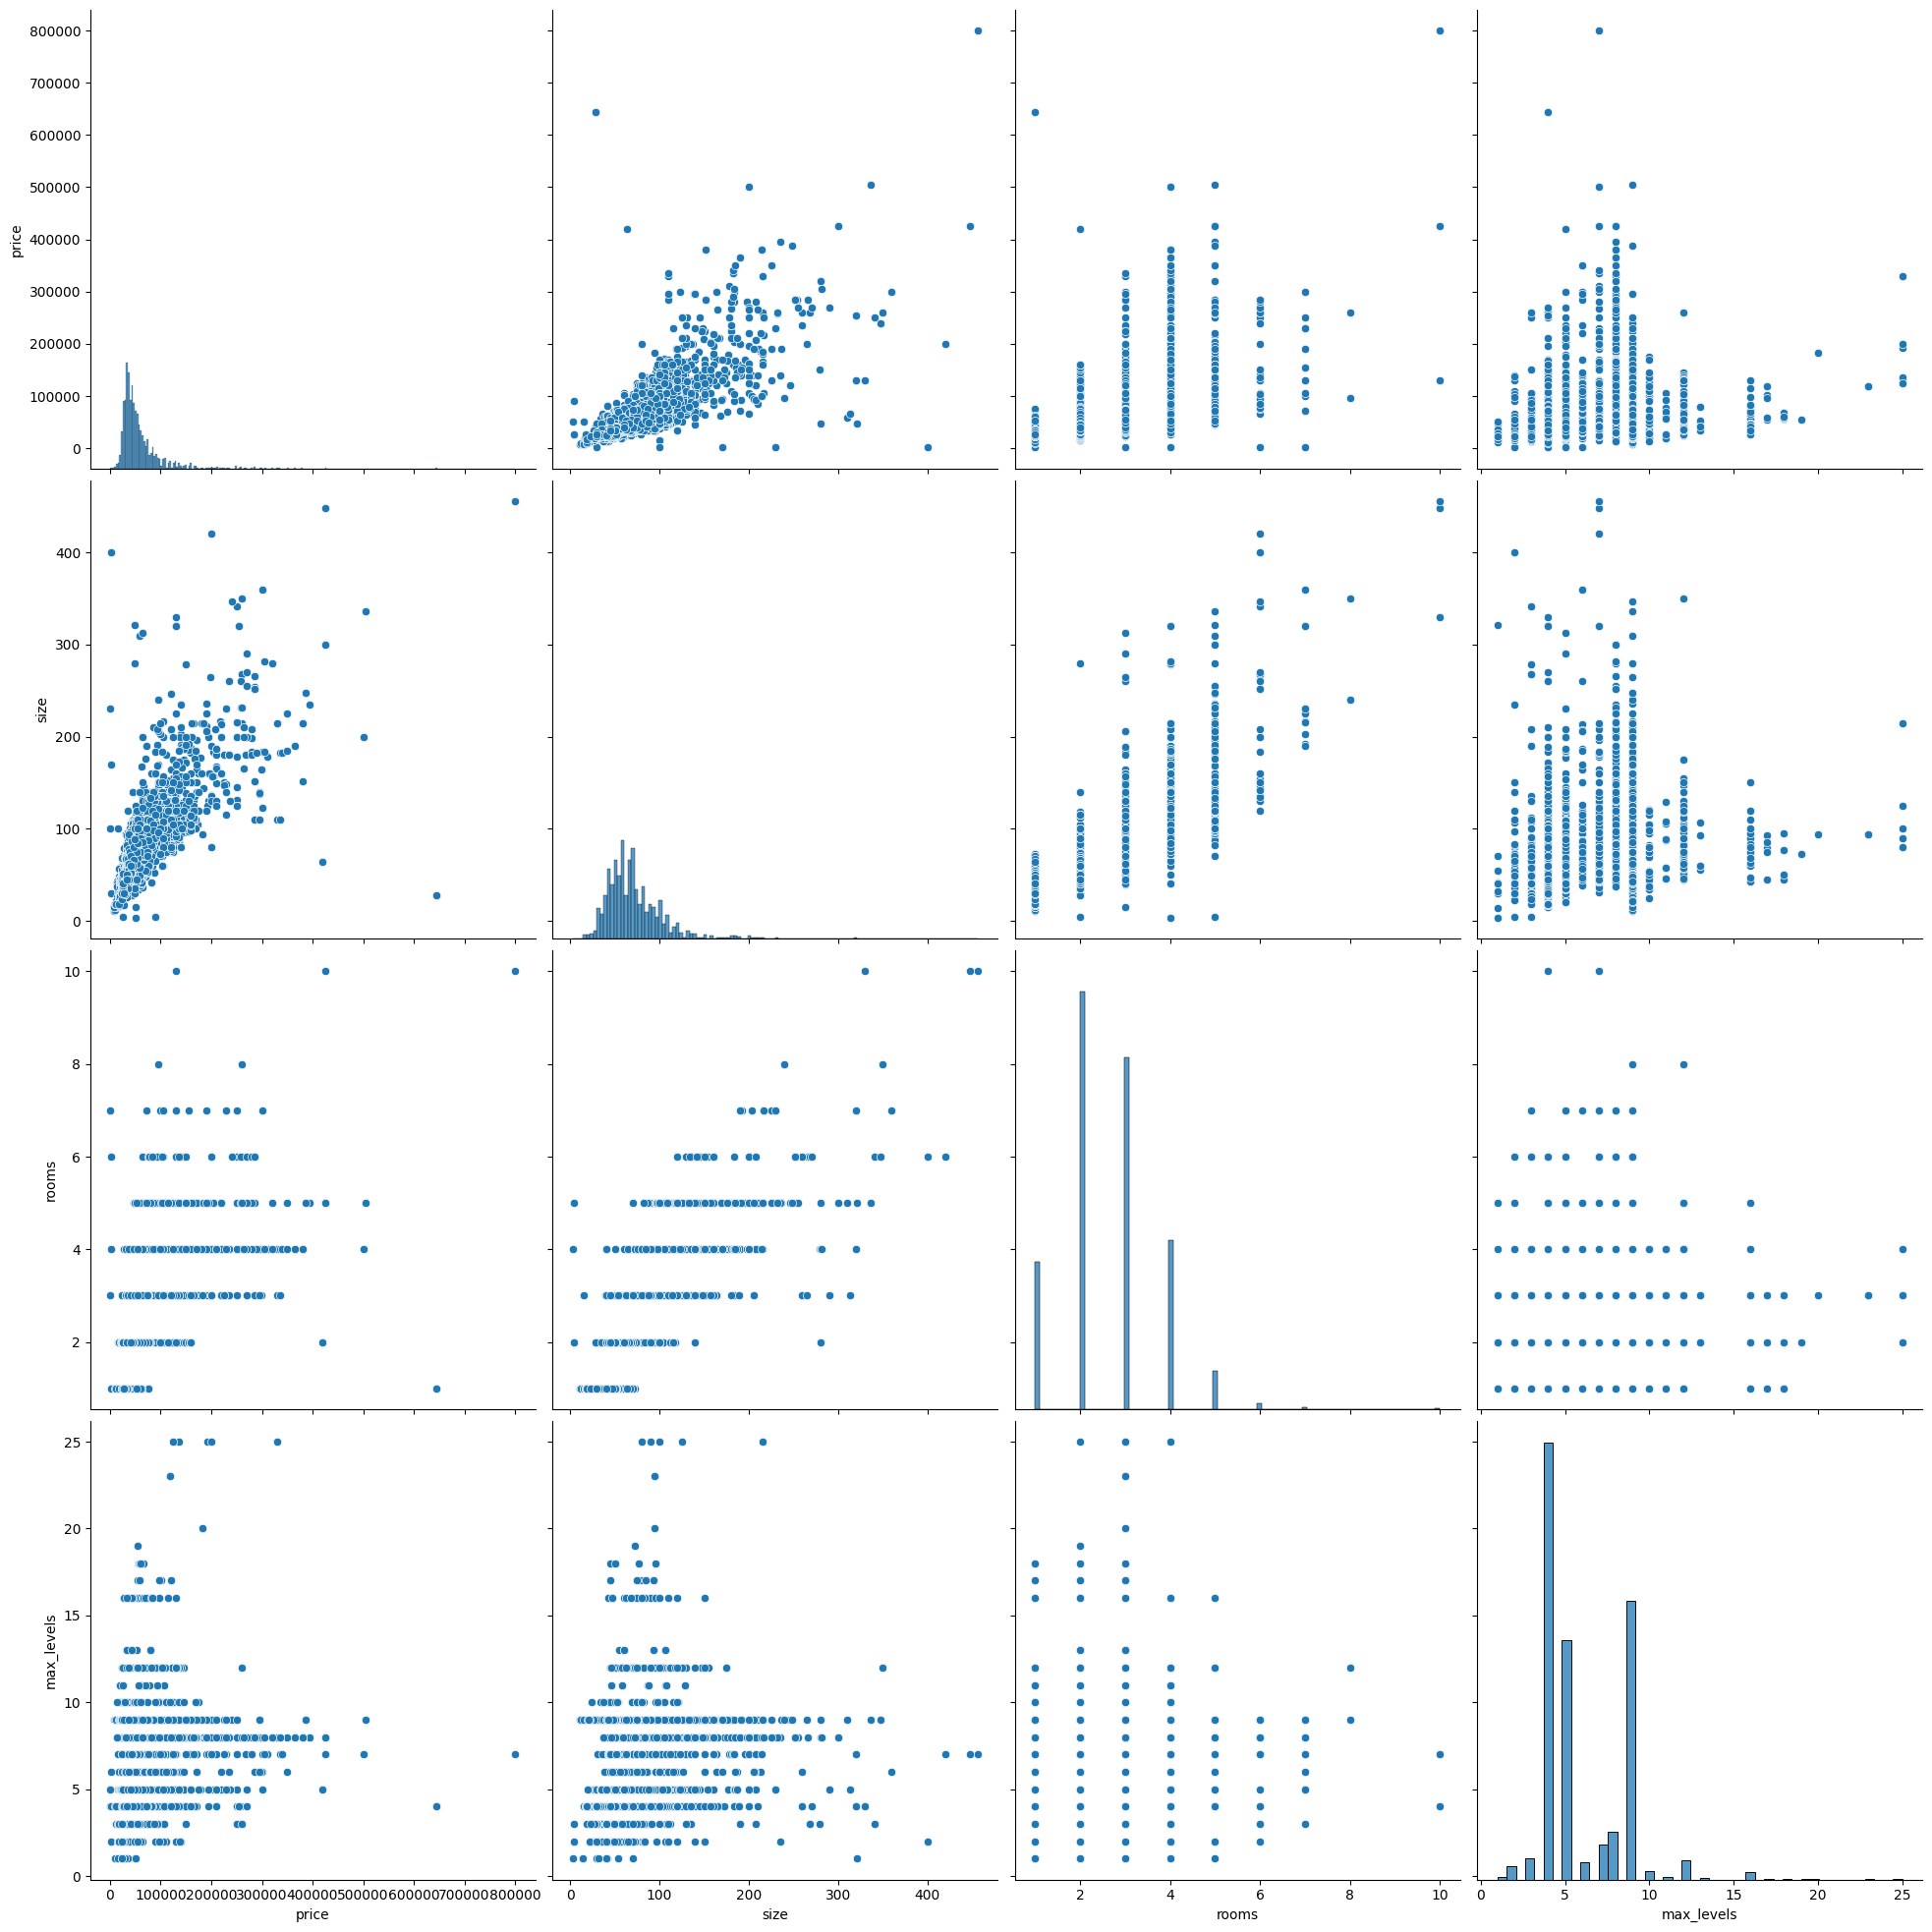

In [22]:
import seaborn as sns
cols = ['price','size','rooms','max_levels']
sns.pairplot(housing[cols],height=5)
plt.show()

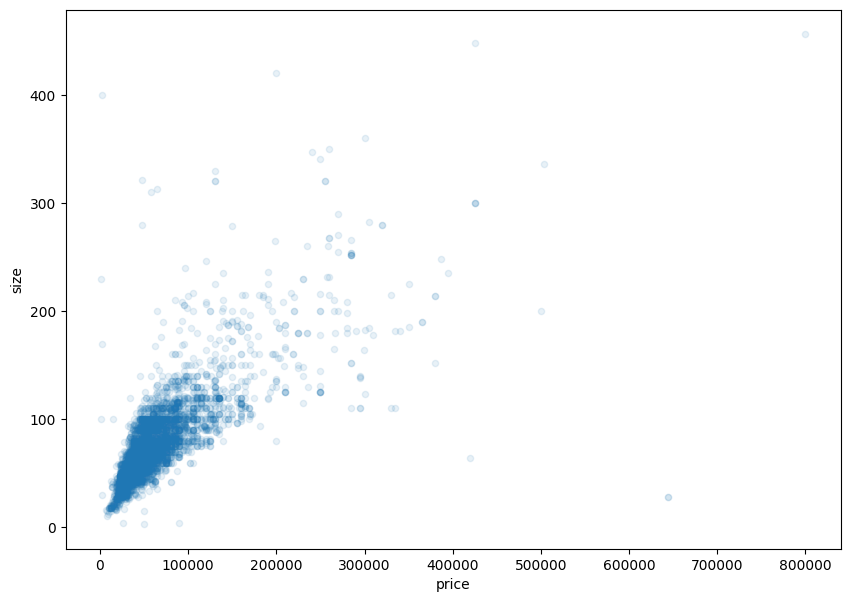

In [23]:
housing.plot(kind='scatter',x='price',y='size',alpha=0.1,figsize=(10,7))
plt.show()

In [24]:
housing.corrwith(housing['price'], numeric_only=True).sort_values(ascending=False)

,0
price,1.000000
size,0.761635
rooms,0.538588
max_levels,0.224509
level,0.069912


Initially, I observed that the strongest correlation in the dataset was between size and price.
To improve the relationship with the target variable, I created new features:

*price_per_room

*price_per_m2

*size_per_room

After adding these features, I achieved significantly better results.
In particular, the price_per_room feature showed a very strong correlation, and the others also performed well and improved the overall analysis.

In [28]:
housing['price_per_room'] = housing['price'] / housing['rooms']
housing['size_per_room'] = housing['size'] / housing['rooms']
housing['price_per_m2'] = housing['price'] / housing['size']
housing.head()

,location,district,rooms,size,level,max_levels,price,price_per_m2,size_per_room,price_per_room
761,"город Ташкент, Олмазорский район, Бируни-1",Олмазорский,4,150,5,6,95000,633.333333,37.500000,23750.0
1522,"город Ташкент, Чиланзарский район, Домбрабад",Чиланзарский,1,42,3,9,31500,750.000000,42.000000,31500.0
1938,"город Ташкент, Яккасарайский район, Кушбеги",Яккасарайский,3,76,5,9,43500,572.368421,25.333333,14500.0
4285,"город Ташкент, Мирзо-Улугбекский район, Феруза 1",Мирзо-Улугбекский,2,48,1,4,28000,583.333333,24.000000,14000.0
4117,"город Ташкент, Юнусабадский район, Киёт",Юнусабадский,1,43,3,4,39000,906.976744,43.000000,39000.0


In [29]:
housing.corrwith(housing['price'], numeric_only=True).sort_values(ascending=False)

,0
price,1.000000
size,0.761635
price_per_room,0.670780
rooms,0.538588
price_per_m2,0.438931
size_per_room,0.338070
max_levels,0.224509
level,0.069912
